# **02: Distillation of NLP models on SST-2**

This notebook will not explain again what was explained in the previous tutorial, such as basic Loss, the Distiller, the metrics, etc. Please check it first to fully understand this notebook that will illustrate how to do the following:
* Adapt an already existing framework to match `shrinkai`
* Use `AttentionMapLoss` for knowledge distillation at intermediate levels

The use case example would be the SST-2, a benchmark dataset in NLP used to train and test text classification models. The goal here is not to reach state-of-the-art performance but to show how to use `shrinkai` effectively for knowledge distillation. 

## **Setup**

In [17]:
import torch
import tutorial_utils
from datasets import load_dataset
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from shrinkai.adapters import FeatureExtractor
from shrinkai.distillation import Distiller
from shrinkai.distillation.losses import HintonLoss, HybridLoss, ProjectedFeatureLoss

## **Adapt HuggingFace to match ShrinkAI**

First of all, HuggingFace frameworks have their own logic and architecture. To perform distillation with `shrinkai`, the model API must be customized to fit `shrinkai` logic. During the first tutorial, `FeatureExtractor` was introduced to capture intermediate states, but it could be easier to deal with that problem directly in the models class. In the example, a custom `FeatureExtractor` adapted for HuggingFace will be created.

**Note**: `SequenceClassificationWrapper` subclasses `FeatureExtractor` only so that `Distiller`'s `isinstance(..., FeatureExtractor)` checks (used by `feature_analysis`) still pass. Its `__init__` deliberately calls `super(FeatureExtractor, self).__init__()` to skip `FeatureExtractor`'s own hook-registration logic, which expects an already-built model instance rather than a HuggingFace model name to load. The wrapper implements its own `forward()` below instead, calling the HuggingFace model directly with `output_attentions=True` and returning `(logits, features_dict)` itself.

In [ ]:
class SequenceClassificationWrapper(FeatureExtractor):
    """Adapt a Hugging Face model to work with the ShrinkAI engine."""

    def __init__(
        self,
        model_name: str,
        pad_token_id: int,
        layer_mapping: dict[int, str],
        num_labels: int = 2,
    ):
        super(FeatureExtractor, self).__init__()
        self.hf_model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=num_labels,
            ignore_mismatched_sizes=True,
            attn_implementation="eager",
            # Most libraries default to `sdpa` attention, which doesn't materialize
            # the attention matrix; we need "eager" here since we do need it below.
        )
        self.pad_token_id = pad_token_id
        self.target_layers = layer_mapping

    def forward(self, input_ids: torch.Tensor) -> tuple[torch.Tensor, dict[str, torch.Tensor]]:
        attention_mask = (input_ids != self.pad_token_id).long()
        # We force the output of the calculations so that the inner layers can be computed
        outputs = self.hf_model(
            input_ids=input_ids, attention_mask=attention_mask, output_attentions=True
        )
        # We capture intermediate attention matrices
        features_dict = {}
        if outputs.attentions is not None:
            for layer_idx, alias in self.target_layers.items():
                features_dict[alias] = outputs.attentions[layer_idx]

        # To match ShrinkAI logic, the forward method must return a tuple with the logits
        # and the features dict
        return outputs.logits, features_dict

Let's prepare the data and the models.

In [3]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
dataset = load_dataset("nyu-mll/glue", "sst2")

In [4]:
def tokenize_data(data):
    encodings = tokenizer(
        data["sentence"],
        padding="max_length",
        truncation=True,
        max_length=64,
        return_tensors="pt",
    )
    return encodings["input_ids"], torch.tensor(data["label"])

In [5]:
def build_sst2_dataloaders(
    dataset,
    tokenizer,
    batch_size: int = 64,
    max_length: int = 64,
    train_subset_size: int = 20000,
) -> tuple[DataLoader, DataLoader, torch.Tensor]:
    train_data = dataset["train"].select(range(min(train_subset_size, len(dataset["train"]))))
    val_data = dataset["validation"]

    def tokenize_function(examples):
        return tokenizer(
            examples["sentence"],
            padding="max_length",
            truncation=True,
            max_length=max_length,
        )

    tokenized_train, tokenized_val = (
        train_data.map(tokenize_function, batched=True),
        val_data.map(tokenize_function, batched=True),
    )
    tokenized_train.set_format(type="torch", columns=["input_ids", "label"])
    tokenized_val.set_format(type="torch", columns=["input_ids", "label"])

    train_dataset = TensorDataset(tokenized_train[:]["input_ids"], tokenized_train[:]["label"])
    val_dataset = TensorDataset(tokenized_val[:]["input_ids"], tokenized_val[:]["label"])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    sample_input = tokenized_val["input_ids"][:batch_size]

    return train_loader, val_loader, sample_input

In [6]:
train_loader, val_loader, sample_input = build_sst2_dataloaders(dataset, tokenizer)

In [7]:
# 12 layers, 12 attention heads, finetuned for SST-2
teacher_id = "textattack/bert-base-uncased-SST-2"
# 2 layers, 2 attention heads
student_id = "google/bert_uncased_L-2_H-128_A-2"

## **Attention Map Loss**

In [8]:
from shrinkai.adapters import AttentionHeadSelector
from shrinkai.distillation.losses import AttentionMapLoss

While standard Feature-Based Distillation aligns the hidden states of neural networks, **Attention-Based Distillation** forces the student to mimic how the teacher connects and understands words. Introduced in landmark papers like *TinyBERT* (2019) and *MiniLM* (2020), this approach directly aligns the self-attention matrices of Transformer models.

$$L_{attention}\left(A_{student}, A_{teacher}\right) = \text{Distance}\left(A_{student}, S(A_{teacher})\right)$$

with:

* **$A_{student}$**: The attention probability matrix extracted from the student model (shape: `[Batch, Heads_student, Seq_Len, Seq_Len]`).
* **$A_{teacher}$**: The attention probability matrix extracted from the teacher model (shape: `[Batch, Heads_teacher, Seq_Len, Seq_Len]`).
* **$S$ (Selector)**: A mapping function applied to the *teacher's* attention maps. Because a student (e.g., TinyBERT) has significantly fewer attention heads than the teacher (e.g., 2 vs 12), the matrices cannot be compared directly. The selector slices the teacher's tensor to keep only the specific heads that the student is meant to mimic.
* **$\text{Distance}$**: The metric used to compute the difference between the two attention maps (typically Mean Squared Error on unnormalized logits, or KL Divergence on softmax probabilities).

This Loss function is the key behind ultra-compressed NLP models. By transferring attention maps, the student inherits the teacher's deep understanding of syntax, grammar, and contextual word relationships. However, much like intermediate feature extraction, distilling attention poses a major architectural challenge: a mismatch in the number of attention heads. 

To solve this for Transformers, `shrinkai` adapts its feature toolkit with 3 powerful components:

* `AttentionHeadSelector`: Acts as the $S$ function in the equation above. It dynamically slices the teacher's massive attention tensor to isolate only the target heads (e.g., reducing `12` heads down to `2`).
* `ProjectedFeatureLoss`: The exact same bridge used in Vision, but configured with `project_teacher=True`. This flag flips the internal logic. Instead of upscaling the student's dimensions, it applies the `AttentionHeadSelector` to downscale the teacher's dimensions before calculating the final `AttentionMapLoss`.

In [9]:
# According to our custom class SequenceClassificationWrapper and the models' architecture
teacher_mapping = {5: "attention_layer_1", 11: "attention_layer_2"}
student_mapping = {0: "attention_layer_1", 1: "attention_layer_2"}

teacher = SequenceClassificationWrapper(teacher_id, tokenizer.pad_token_id, teacher_mapping)
student = SequenceClassificationWrapper(student_id, tokenizer.pad_token_id, student_mapping)

Loading weights: 100%|██████████| 39/39 [00:00<00:00, 19616.00it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: google/bert_uncased_L-2_H-128_A-2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing fr

In [10]:
attention_loss = ProjectedFeatureLoss(
    projector=AttentionHeadSelector(heads_to_keep=[0, 6]),
    feature_loss=AttentionMapLoss(loss_type="mse"),
    project_teacher=True,  # IMPORTANT for Transformer architecture
)

In [11]:
loss = HybridLoss(
    logit_loss=HintonLoss(temperature=4.0),
    feature_loss=attention_loss,
    feature_weight=10,  # strong weight because MSE on softmax tends to be small
    convex_weighting=False,
)

In [12]:
distiller = Distiller(
    teacher=teacher,
    student=student,
    criterion=loss,
    optimizer="adamw",
    lr=5e-4,
    weight_decay=0.01,
    device="auto",
)

In [13]:
training_history = distiller.fit(train_loader, val_loader, epochs=4)

Epoch [01/04] Train Loss: 1.1967 - Train Acc: 81.16% | Val Loss: 1.2999 - Val Acc: 77.18%


Epoch [02/04] Train Loss: 0.5854 - Train Acc: 90.98% | Val Loss: 1.1959 - Val Acc: 79.24%


Epoch [03/04] Train Loss: 0.3821 - Train Acc: 93.94% | Val Loss: 1.3389 - Val Acc: 79.24%


Epoch [04/04] Train Loss: 0.2929 - Train Acc: 95.53% | Val Loss: 1.3496 - Val Acc: 79.70%


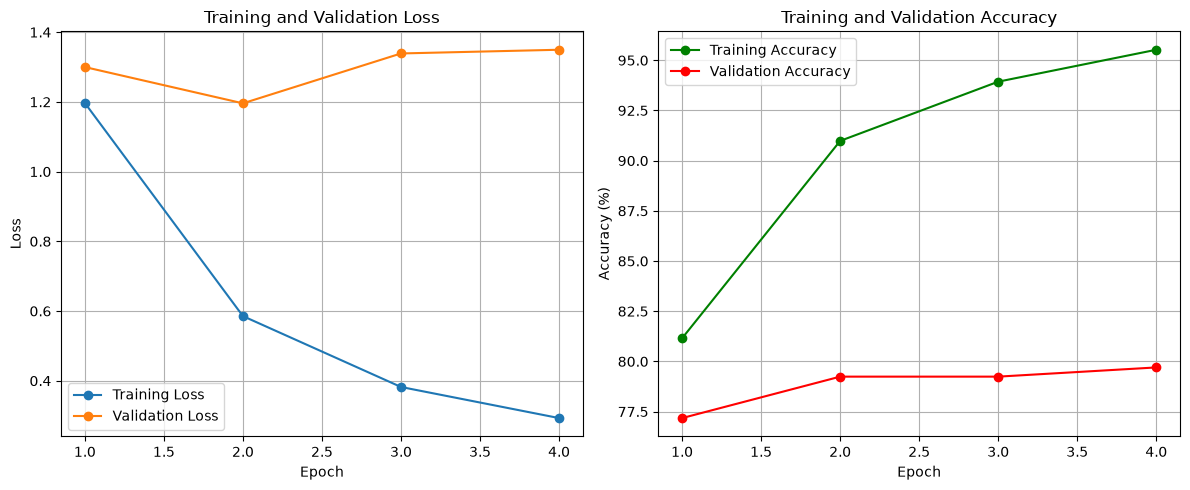

In [14]:
tutorial_utils.plot_history(training_history)

Keep in mind that distillation is not immune to overfitting, it can still happen here, especially with only a few epochs and a training subset.

In [19]:
distiller.benchmark(
    sample_input=sample_input,
    teacher_name=teacher_id,
    student_name=student_id,
    val_dataloader=val_loader,
).show()

                                           Distillation Benchmark Report                                           
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                   ┃                         Teacher ┃                          Student ┃                        ┃
┃ Metric            ┃ (textattack/bert-base-uncased-… ┃ (google/bert_uncased_L-2_H-128_… ┃     Gain / Compression ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Parameters        │                        109.48 M │                           4.39 M │                 -96.0% │
│ Model Size (Disk) │                       417.73 MB │                         16.75 MB │ -96.0% (24.9x smaller) │
│ Latency / Sample  │                        11.65 ms │                          0.26 ms │           45.0x faster │
│ Throughput (FPS)  │                      85.8 img/s │                     3863.9 img/s │    +45.0x (3863.9 FPS) │
│ Accuracy          │                          92.43% │                           79.70% │         86.2% retained │
└───────────────────┴─────────────────────────────────┴──────────────────────────────────┴────────────────────────┘

In [16]:
distiller.feature_analysis(val_loader, metrics=["cka", "rsa", "attention"]).show()

          Representation Alignment Report (Feature Distillation)          
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer / Stage Alias ┃ CKA (Linear) ┃ RSA (Pearson) ┃ Spatial Attention ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ attention_layer_1   │        0.963 │         0.973 │             0.798 │
│ attention_layer_2   │        0.863 │         0.726 │             0.761 │
└─────────────────────┴──────────────┴───────────────┴───────────────────┘

## **References**

1. Vaswani, A., et al. (2017). *Attention Is All You Need*. NeurIPS. arXiv:1706.03762.  
   https://arxiv.org/abs/1706.03762

2. Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. NAACL-HLT. arXiv:1810.04805.  
   https://arxiv.org/abs/1810.04805

3. Hinton, G., Vinyals, O., & Dean, J. (2015). *Distilling the Knowledge in a Neural Network*. arXiv:1503.02531.  
   https://arxiv.org/abs/1503.02531

4. Jiao, X., et al. (2020). *TinyBERT: Distilling BERT for Natural Language Understanding*. Findings of EMNLP. arXiv:1909.10351.  
   https://arxiv.org/abs/1909.10351

5. Wang, W., et al. (2020). *MiniLM: Deep Self-Attention Distillation for Task-Agnostic Compression of Pre-Trained Transformers*. NeurIPS. arXiv:2002.10957.  
   https://arxiv.org/abs/2002.10957

6. Sun, S., Cheng, Y., Gan, Z., & Liu, J. (2019). *Patient Knowledge Distillation for BERT Model Compression*. EMNLP. arXiv:1908.09355.  
   https://arxiv.org/abs/1908.09355

7. Romero, A., et al. (2015). *FitNets: Hints for Thin Deep Nets*. ICLR. arXiv:1412.6550.  
   https://arxiv.org/abs/1412.6550

8. Zagoruyko, S., & Komodakis, N. (2017). *Paying More Attention to Attention: Improving the Performance of Convolutional Neural Networks via Attention Transfer*. ICLR. arXiv:1612.03928.  
   https://arxiv.org/abs/1612.03928

9. Michel, P., Levy, O., & Neubig, G. (2019). *Are Sixteen Heads Really Better than One?* NeurIPS. arXiv:1905.10650.  
   https://arxiv.org/abs/1905.10650

10. Wang, A., et al. (2018). *GLUE: A Multi-Task Benchmark and Analysis Platform for Natural Language Understanding*. EMNLP Workshop. arXiv:1804.07461.  
    https://arxiv.org/abs/1804.07461

11. Socher, R., et al. (2013). *Recursive Deep Models for Semantic Compositionality Over a Sentiment Treebank*. EMNLP.  
    https://aclanthology.org/D13-1170/

12. Loshchilov, I., & Hutter, F. (2019). *Decoupled Weight Decay Regularization*. ICLR. arXiv:1711.05101.  
    https://arxiv.org/abs/1711.05101

13. Kornblith, S., Norouzi, M., Lee, H., & Hinton, G. (2019). *Similarity of Neural Network Representations Revisited*. ICML. arXiv:1905.00414.  
    https://arxiv.org/abs/1905.00414

14. Kriegeskorte, N., Mur, M., & Bandettini, P. (2008). *Representational Similarity Analysis – Connecting the Branches of Systems Neuroscience*. Frontiers in Systems Neuroscience.